# Spectral descent in a few lines

The penalized LMO minimizes $\langle G,V\rangle+\|V\|_{S_{2p}}^2/2$.
At $p=1$ it is $-G$; at $p=\infty$ it is the negative polar factor
multiplied by $\|G\|_*$, not just the polar factor.

Run from an environment with `pip install -e '.[notebooks,transport]'` from
the repository root. In Colab, first run
`%pip install 'muon-dynamics[notebooks,transport] @ git+https://github.com/gpeyre/muon-dynamics.git'`.
All particle arrays have particles in rows. No training data are downloaded.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import muon_dynamics as md

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})


Matplotlib is building the font cache; this may take a moment.


In [2]:
G = np.diag([4., 1., .2])
ps = [0.5, 1, 2, np.inf]
velocities = [md.schatten_lmo(G, p) for p in ps]
for p, V in zip(ps, velocities):
    action = md.schatten_norm(V, 2*p)**2
    np.testing.assert_allclose(np.sum(G*V), -action)
    print(f"p={p:g}: dissipation = {action:.4f}")


p=0.5: dissipation = 16.0000
p=1: dissipation = 17.0400
p=2: dissipation = 20.4024
p=inf: dissipation = 27.0400


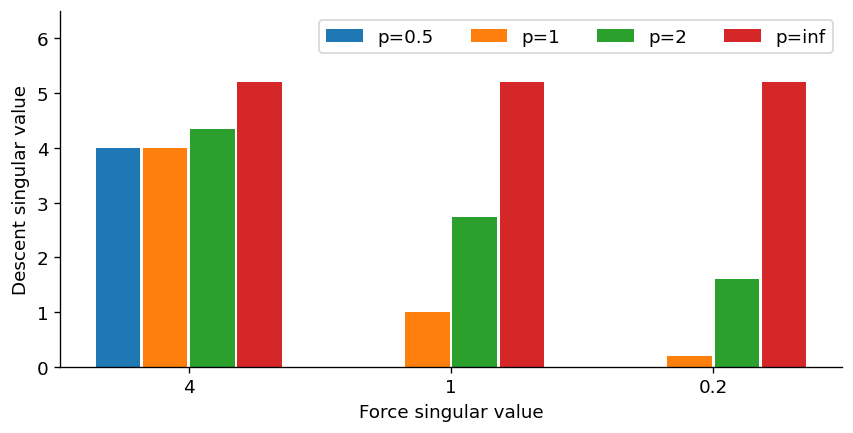

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
for j, (p, V) in enumerate(zip(ps, velocities)):
    ax.bar(np.arange(3) + .18*j, -np.diag(V), width=.17, label=f"p={p:g}")
ax.set(xticks=np.arange(3)+.27, xticklabels=["4", "1", "0.2"],
       xlabel="Force singular value", ylabel="Descent singular value")
ax.set_ylim(0, 6.5)
ax.legend(ncol=4)
fig.savefig("01_spectral_directions.png", dpi=130)
plt.show()


## From matrices to measures

`particle_lmo(g, p, weights)` takes the spatial force $g(x_i)$.
If automatic differentiation returns $\nabla_{x_i}F$, divide it by
the particle weight first. For uniform weights this is a factor $n$.
`block_lmo(G, [d1, d2], p)` instead normalizes two parameter blocks
independently, with one dual-norm scale per block.


In [4]:
weights = np.array([.2, .3, .5])
V = md.particle_lmo(G, np.inf, weights)
np.testing.assert_allclose(np.sum(weights[:, None]*G*V),
                           -md.velocity_norm(V, np.inf, weights)**2)
print("Weighted dissipation identity verified.")


Weighted dissipation identity verified.
